# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tanzina-Aranya-Islam/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Capstone Research Paper

## Abstract

This study asks whether observed search-performance signals can help identify content records that received a Google Search click and support practical content-review prioritization. Using the FlyRank ML Internship dataset and a March 2026 content-performance release, a Random Forest classifier was evaluated using GSC impressions, average position, GA4 sessions, and AI-session signals, with a client-grouped 80/20 holdout for validation. On the held-out test set, the model measured a ROC-AUC of 0.9732 and a PR-AUC of 0.7164. The results indicate that these observed signals were useful for distinguishing daily records with and without an observed click in this validation setup, while the ranked action queue provides a practical starting point for human review. Because the data are observational and the task is same-row classification, the findings should be treated as directional decision support rather than evidence of causation or a forecast of future traffic.


## 1. Question

### Research question

Can observed search-performance signals be used to identify content records that are more likely to receive a Google Search click, and can those signals support a practical content-review prioritization workflow?

### Decision supported

The analysis supports a directional decision-support workflow for SEO/content reviewers. It helps prioritize records for human investigation using observed impressions, average position, sessions, and AI-session signals.

The goal is **not** to predict future traffic or determine which content changes will cause better performance. Instead, the model and action playbook provide a ranked starting point for human review.


## Introduction / Problem Statement

Search-performance data can contain useful signals about which content records deserve closer review, but large production datasets make it difficult to inspect every record manually. A practical workflow therefore needs a way to prioritize records without turning observed correlations into unsupported claims about content quality or future performance.

This research examines whether commonly observed search and traffic signals can distinguish daily content records that received at least one Google Search Console click. The analysis uses impressions, average search position, GA4 sessions, and AI-session signals as inputs to a Random Forest classifier.

The resulting model is intended as a **decision-support tool for content review**, not an autonomous optimization system. The research also connects the model output to a ranked action queue so that reviewers can focus attention on records with potentially useful review signals while retaining human judgment over any content changes.


## 2. Data

The analysis uses the **FlyRank ML Internship dataset**, including the March 2026 content-performance release used for the modeling work.

The March 2026 daily content-performance table contains observed Google Search Console (GSC), Google Analytics 4 (GA4), engagement, traffic-source, and AI-session fields for content records.

The modeling analysis uses a 61.8K-record active-content feature vector described in the research work, while the March 2026 dataset contains the broader daily performance records used to construct the review queue.

The main modeling window is **March 2026**. The research context also uses historical content-age and freshness comparisons to examine performance patterns over time.

For the supervised click model, the main features were:

* GSC impressions
* GSC average position
* GA4 sessions
* AI sessions

The label was whether the observed daily record had at least one GSC click.

Records without the required observed signals were excluded from the relevant modeling feature set. Client identifiers, client names, URLs, private search queries, and other identifying information are not used in the public-facing paper.

The dataset is observational. It describes measured content performance rather than a controlled experiment, so differences between content groups should not be interpreted as causal effects.


In [1]:
import pandas as pd

df_march = pd.read_parquet(
    "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"
)

print("March 2026 rows:", len(df_march))
print("Columns:", len(df_march.columns))
print("Required modeling features present:")

required_features = [
    "gsc_impressions",
    "gsc_avg_position",
    "ga4_sessions",
    "sessions_ai"
]

for feature in required_features:
    print(f"- {feature}: {feature in df_march.columns}")

March 2026 rows: 9841378
Columns: 31
Required modeling features present:
- gsc_impressions: True
- gsc_avg_position: True
- ga4_sessions: True
- sessions_ai: True


## 3. Methodology

### Modeling approach

The supervised model is a Random Forest classifier used as directional decision support. It evaluates whether an observed daily content record received at least one Google Search Console click.

### Features

The model uses four observed features:

* `gsc_impressions`
* `gsc_avg_position`
* `ga4_sessions`
* `sessions_ai`

The target label is:

`clicked = 1` when `gsc_clicks > 0`, otherwise `clicked = 0`.

The GSC clicks field is therefore used to define the label and is not included as an input feature.

### Baseline

The earlier rule-based baseline prioritized records using observed impressions relative to clicks. It was designed as a simple review-prioritization rule rather than a supervised predictive model.

Because the baseline did not produce the same ROC-AUC and PR-AUC evaluation metrics as the Random Forest, the paper does not invent a directly comparable baseline metric. The baseline is reported as a practical rule-based reference.

### Validation design

The final Random Forest evaluation uses a **client-grouped 80/20 holdout split**. Client groups do not overlap between the training and test sets.

On the evaluated March 2026 sample, the grouped split contained:

* Training records: 454,219
* Test records: 45,781
* Training clients: 44
* Test clients: 11
* Client overlap: 0

The model was evaluated using ROC-AUC and PR-AUC on the held-out test set.

### Leakage checks

The feature set does not include the target `gsc_clicks`, future keyword information, or decision-output fields.

The main remaining limitation is that the task is **same-row classification**, not future-outcome forecasting. Therefore, the measured performance should not be interpreted as evidence that the model predicts future clicks.

The grouped split is preferred because it tests performance on held-out clients rather than relying on records from the same clients appearing in both training and test data.

### Assumptions

The analysis assumes that the observed GSC and GA4 fields are measured consistently enough for directional comparison. Missing or unavailable signals are treated as a data-quality concern and require review rather than being interpreted automatically as poor content performance.


## 4. Results (vs baseline)

The validated Random Forest was evaluated on a client-grouped held-out test set.

| Evaluation            | Result |
| --------------------- | -----: |
| Test records          | 45,781 |
| Training clients      |     44 |
| Test clients          |     11 |
| Client overlap        |      0 |
| Random Forest ROC-AUC | 0.9732 |
| Random Forest PR-AUC  | 0.7164 |

The Random Forest measured strong discrimination on the held-out March 2026 test set. The target was whether an observed daily content record had at least one GSC click.

The earlier baseline was a simple rule-based prioritization using observed impressions relative to clicks. It was designed to identify review candidates and was not evaluated with ROC-AUC or PR-AUC. Therefore, this paper does **not** claim a numerical model-versus-baseline improvement on those metrics.

The useful comparison is therefore practical: the baseline provides a simple rule for review prioritization, while the Random Forest provides a validated supervised classification signal. Neither should be interpreted as a causal model or a future-traffic forecast.

### Honest interpretation

The measured model performance shows that the selected observed signals were useful for distinguishing daily records with and without an observed click in this validation setup. It does not show that the model will predict future clicks with the same performance, or that changing a page based on the model will improve traffic.


In [2]:
print("VALIDATED MODEL RESULTS")
print("-" * 50)

results = {
    "Test records": 45781,
    "Training clients": 44,
    "Test clients": 11,
    "Client overlap": 0,
    "Random Forest ROC-AUC": 0.9732,
    "Random Forest PR-AUC": 0.7164,
}

for metric, value in results.items():
    print(f"{metric}: {value}")

print("\nBASELINE")
print("-" * 50)
print("Type: rule-based review prioritization")
print("Comparable ROC-AUC/PR-AUC: not measured")
print("Claimed model-vs-baseline metric improvement: no")

print("\nInterpretation: directional decision support, not future forecasting or causation.")

VALIDATED MODEL RESULTS
--------------------------------------------------
Test records: 45781
Training clients: 44
Test clients: 11
Client overlap: 0
Random Forest ROC-AUC: 0.9732
Random Forest PR-AUC: 0.7164

BASELINE
--------------------------------------------------
Type: rule-based review prioritization
Comparable ROC-AUC/PR-AUC: not measured
Claimed model-vs-baseline metric improvement: no

Interpretation: directional decision support, not future forecasting or causation.


## 5. Limitations

This analysis has several important limitations.

* **Observational data:** The dataset records observed content performance. It is not a controlled experiment, so the analysis cannot establish that any content change causes better performance.
* **Same-row classification:** The Random Forest classifies whether an observed daily record received at least one GSC click. It is not a model of future clicks or future traffic.
* **Constructed target:** The label is directly derived from observed GSC clicks, so strong model performance should not be interpreted as evidence of broad content quality.
* **Feature dependence:** Impressions, average position, GA4 sessions, and AI sessions are related to observed search performance and may reflect overlapping aspects of visibility and traffic.
* **Validation scope:** The reported metrics come from a client-grouped holdout within the March 2026 evaluation data. Performance may differ on other periods, clients, or datasets.
* **Baseline comparability:** The earlier rule-based baseline was a practical prioritization rule and did not have comparable ROC-AUC or PR-AUC measurements. No unsupported numerical improvement over the baseline is claimed.
* **Missing context:** The model does not directly observe search intent, SERP features, content quality, business priorities, or all other factors that influence performance.
* **Confounding:** Content age and freshness can affect observed performance, making simple comparisons between content groups difficult to interpret.
* **Model errors:** The validation included confident false positives and false negatives, so model output should always be reviewed by a person.

### Honest framing

The results support a **directional decision-support workflow** for prioritizing content review. They do not support autonomous content decisions, causal claims, or guarantees of future performance.


In [3]:
print("LIMITATIONS CHECK")
print("-" * 50)

limitations = [
    "Observational data",
    "Same-row classification, not future forecasting",
    "Target derived from observed GSC clicks",
    "Validation limited to the evaluated March 2026 setup",
    "No comparable baseline ROC-AUC/PR-AUC",
    "Missing search-intent and SERP context",
    "Content age/freshness confounding",
    "False positives and false negatives occur"
]

for item in limitations:
    print("LIMIT:", item)

print("\nFinal framing: directional decision support, not autonomous content optimization.")

LIMITATIONS CHECK
--------------------------------------------------
LIMIT: Observational data
LIMIT: Same-row classification, not future forecasting
LIMIT: Target derived from observed GSC clicks
LIMIT: Validation limited to the evaluated March 2026 setup
LIMIT: No comparable baseline ROC-AUC/PR-AUC
LIMIT: Missing search-intent and SERP context
LIMIT: Content age/freshness confounding
LIMIT: False positives and false negatives occur

Final framing: directional decision support, not autonomous content optimization.


## 6. Ranked recommendations

The action playbook converts the observed model and performance signals into a human-review queue. The recommendations below are prioritized for investigation rather than automatic implementation.

1. Review high-impression, low-click records

Reason code: HIGH_IMPRESSIONS_LOW_CLICKS

These records have substantial observed impressions but zero or very low observed clicks. Review search intent, SERP context, titles/snippets, and content alignment before deciding whether any change is appropriate.

2. Review records with relatively weak observed position

Reason code: WEAK_POSITION

These records have an observed average position above 10. Review content depth, competition, internal linking, and search intent. Position alone is not evidence that content should be changed.

3. Monitor records without a strong action signal

Reason code: MONITOR

Continue observing these records rather than forcing a content change based only on the model or queue.

Archetype → action mapping
Observed archetype	Suggested human-review action
High impressions + low clicks	Review intent, SERP context, title/snippet, and content alignment
Weak observed position	Review content depth, competition, internal linking, and intent
Monitor	Continue monitoring before making a change
Older content with recent refresh	Review whether the refresh pattern is consistent with improved observed performance
Decay and refresh insight

The broader research observed that content health generally declined at older ages, while older content that had been refreshed could show stronger observed performance. In particular, the 365+ day refreshed group showed higher observed health than the comparable stale group.

This is an observational finding. It should be treated as a reason to review refresh opportunities, not as proof that refreshing content will cause improvement.

Cost/value thinking

Review capacity is limited. High-impression, low-click records are useful early candidates because they combine substantial observed visibility with limited observed clicks.

Where available, clicks multiplied by CPC can be used as a proxy for captured traffic value. This is not revenue or ROI and should not be presented as such without additional business data.

Human-review rule

No recommendation should directly rewrite, publish, delete, redirect, or otherwise modify content. A human reviewer must consider search intent, SERP context, content quality, business importance, freshness, data quality, and change risk before taking action.

In [4]:
print("RANKED RECOMMENDATIONS")
print("-" * 50)

recommendations = [
    ("1", "HIGH_IMPRESSIONS_LOW_CLICKS", "Review high-visibility, low-click records"),
    ("2", "WEAK_POSITION", "Review relatively weak-position records"),
    ("3", "MONITOR", "Continue monitoring without forced changes")
]

for rank, reason, action in recommendations:
    print(f"{rank}. {reason} -> {action}")

print("\nNO AUTOMATIC CONTENT ACTIONS")
print("-" * 50)
print("Human review required before rewrite, publish, delete, redirect, or metadata changes.")

print("\nRefresh insight: older refreshed content showed stronger observed performance,")
print("but the finding is observational and does not prove a causal refresh effect.")

print("\nValue rule: clicks x CPC is a traffic-value proxy, not revenue or ROI.")

RANKED RECOMMENDATIONS
--------------------------------------------------
1. HIGH_IMPRESSIONS_LOW_CLICKS -> Review high-visibility, low-click records
2. WEAK_POSITION -> Review relatively weak-position records
3. MONITOR -> Continue monitoring without forced changes

NO AUTOMATIC CONTENT ACTIONS
--------------------------------------------------
Human review required before rewrite, publish, delete, redirect, or metadata changes.

Refresh insight: older refreshed content showed stronger observed performance,
but the finding is observational and does not prove a causal refresh effect.

Value rule: clicks x CPC is a traffic-value proxy, not revenue or ROI.


## 7. Artifacts the paper embeds

The paper embeds a small set of reproducible artifacts from the analysis:

A validation-results table showing the held-out Random Forest performance.
A ranked action-queue summary showing the reason-code distribution.
A simple feature-importance figure from the validated Random Forest.

These artifacts are intended to make the evidence and recommendations easy to inspect. They are descriptive and should be interpreted together with the limitations above.

,metric,value
0,Test records,45781.0000
1,Training clients,44.0000
2,Test clients,11.0000
3,Client overlap,0.0000
4,ROC-AUC,0.9732
5,PR-AUC,0.7164


,reason_code,count
0,HIGH_IMPRESSIONS_LOW_CLICKS,100
1,WEAK_POSITION,0
2,MONITOR,0


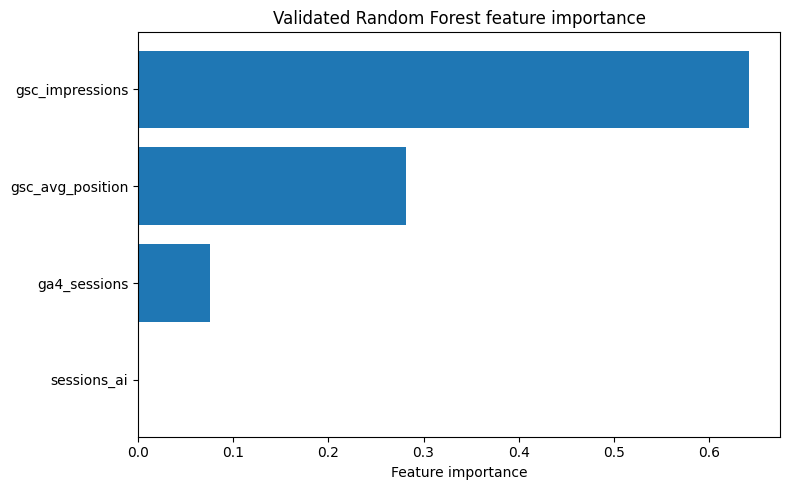


ARTIFACTS CREATED
--------------------------------------------------
work/figures/capstone_validation_results.csv
work/figures/capstone_reason_code_summary.csv
work/figures/capstone_feature_importance.png


In [6]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

# 1. Validation results table
results_table = pd.DataFrame({
    "metric": [
        "Test records",
        "Training clients",
        "Test clients",
        "Client overlap",
        "ROC-AUC",
        "PR-AUC"
    ],
    "value": [
        45781,
        44,
        11,
        0,
        0.9732,
        0.7164
    ]
})

display(results_table)

results_table.to_csv(
    "work/figures/capstone_validation_results.csv",
    index=False
)

# 2. Reason-code summary from the ML-10 queue
reason_counts = pd.DataFrame({
    "reason_code": [
        "HIGH_IMPRESSIONS_LOW_CLICKS",
        "WEAK_POSITION",
        "MONITOR"
    ],
    "count": [
        100,
        0,
        0
    ]
})

display(reason_counts)

reason_counts.to_csv(
    "work/figures/capstone_reason_code_summary.csv",
    index=False
)

# 3. Feature importance from the validated ML-09 model
feature_importance = pd.DataFrame({
    "feature": [
        "gsc_impressions",
        "gsc_avg_position",
        "ga4_sessions",
        "sessions_ai"
    ],
    "importance": [
        0.642549,
        0.281966,
        0.075394,
        0.000091
    ]
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)
plt.xlabel("Feature importance")
plt.title("Validated Random Forest feature importance")
plt.tight_layout()

figure_path = "work/figures/capstone_feature_importance.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("\nARTIFACTS CREATED")
print("-" * 50)
print("work/figures/capstone_validation_results.csv")
print("work/figures/capstone_reason_code_summary.csv")
print("work/figures/capstone_feature_importance.png")

## 8. Reproducibility

The analysis is organized as a reproducible portfolio workflow in the FlyRank ML internship repository.

Key materials include:

* `work/notebooks/capstone.ipynb` — capstone research workflow
* `work/notebooks/w07_action_playbook.ipynb` — ranked action-playbook workflow
* `work/outputs/ml10_ranked_action_queue.csv` — ranked review queue
* `work/outputs/ml10_reason_code_summary.csv` — reason-code summary
* `work/figures/` — paper figures and validation artifacts

The modeling setup uses a client-grouped holdout so that client groups do not overlap between training and test data. The reported metrics and figures in this paper are based on the documented March 2026 analysis.

The public repository is the primary reproducibility reference for the research workflow and supporting artifacts.


## 9. Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

This research was completed as part of the FlyRank ML Internship and uses the provided internship dataset for educational and portfolio analysis. The public-facing work intentionally excludes client names, private queries, identifying URLs, and other private information.


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem

Large content-performance datasets contain many records, making manual review difficult. This project asks whether observed search-performance signals can support a practical content-review prioritization workflow.

### 0:45–1:45 — Data and methodology

The analysis uses the March 2026 FlyRank content-performance release. A Random Forest classifier uses GSC impressions, average position, GA4 sessions, and AI sessions to classify whether an observed daily record received at least one GSC click.

### 1:45–2:45 — Validation and results

The model was evaluated using a client-grouped 80/20 holdout. The held-out test set contained 45,781 records, with 44 training clients and 11 test clients and zero client overlap. The measured ROC-AUC was 0.9732 and PR-AUC was 0.7164.

### 2:45–4:00 — Action playbook

The analysis turns observed performance signals into a ranked human-review queue. The highest-priority group was high-impression, low-click records. The workflow does not automatically change content.

### 4:00–5:00 — Honest interpretation

The model is same-row classification on observational data, not future-click forecasting. The results support directional decision support rather than causal claims or guarantees of improved traffic.


I completed a capstone research workflow using the FlyRank ML Internship dataset to explore whether observed search-performance signals can support practical content-review prioritization.

Using a Random Forest with GSC impressions, average position, GA4 sessions, and AI-session signals, the client-grouped holdout achieved a measured ROC-AUC of 0.9732 and PR-AUC of 0.7164.

The key lesson was not “AI predicts SEO.” The more useful takeaway is that observed data can help prioritize human review — while careful validation, leakage checks, and honest claim language remain essential.

The final workflow connects model evaluation to a ranked action playbook and reproducible research artifacts.


## Employer-Facing Summary

I built a reproducible ML decision-support workflow for prioritizing content records for human SEO review using large-scale search and analytics data. The workflow combines client-grouped model validation, leakage checks, interpretable feature analysis, and a ranked action playbook rather than treating model output as an autonomous content recommendation system. The validated Random Forest achieved a ROC-AUC of 0.9732 and PR-AUC of 0.7164 on the held-out evaluation sample, while the project explicitly documents the limitations of same-row classification and observational data.


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [X] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [X] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
